# Residual decomposition workbench

This notebook answers the Step 1 gate: **does the P&B impact residual carry
predictive information beyond its own components, pretrend and a naive flow term,
and does anything clear realistic costs?**

All features are signed in price direction and known at the completed bar endpoint:

| Symbol | Definition |
|---|---|
| $R_t$ | bar return / trailing 24h volatility |
| $P_t$ | $s_t\widehat y_t$: `pb_activity` prediction, frozen fit calibrated before the month |
| $X_t$ | $R_t-P_t$: the signed residual used so far |
| $q_t$ | $s_t\,|Q_t|/V_{24h}$: linear signed flow, a naive benchmark for $P$ |
| `pre15`, `pre60` | clock-time return ending at bar start / trailing volatility |

Because $X$ is the fixed combination $R-P$, it can only beat free weights on $R$
and $P$ by luck. The informative questions are whether the 1:−1 restriction holds,
and whether $P$ adds anything once $R$, pretrend and $q$ are present.

Forecast regressions are fitted on the preceding 12 months (with an embargo) and
frozen for each test month, January 2023 to May 2026. June–August 2026 are not
used, including as target prices.

In [1]:
from pathlib import Path
import json
import os

os.environ.setdefault('MPLCONFIGDIR', '/tmp/alpha-search-matplotlib')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
from matplotlib.ticker import NullFormatter
import numpy as np
import polars as pl
from IPython.display import Markdown, display
get_ipython().run_line_magic('matplotlib', 'inline')

REPO = Path('/Users/petermillington/Research/market-impact-research')
RESULTS = REPO / 'alpha-search' / 'reports' / 'residual_decomposition_v1'
config = json.loads(
    (REPO / 'alpha-search' / 'configs' / 'residual_decomposition_v1.json').read_text()
)
univariate = pl.read_csv(RESULTS / 'univariate_summary.csv')
fm = pl.read_csv(RESULTS / 'fama_macbeth_summary.csv', infer_schema_length=None)
oos = pl.read_csv(RESULTS / 'oos_summary.csv')
oos_monthly = pl.read_csv(RESULTS / 'oos_monthly.csv')
increments = pl.read_csv(RESULTS / 'oos_increments.csv')
tails = pl.read_csv(RESULTS / 'tail_breakeven.csv')
tail_monthly = pl.read_csv(RESULTS / 'tail_monthly.csv')
entry_delay = pl.read_csv(RESULTS / 'entry_delay.csv')

TAKER = 2 * config['costs_bps_per_side']['taker']
MAKER = 2 * config['costs_bps_per_side']['maker']
SIZES = config['event_sizes']

# Fixed categorical order (never cycled); ink colours for text and reference lines.
SERIES = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300']
INK, MUTED = '#2b2b2b', '#8a8a85'
KEY_MODELS = ['residual', 'bar_return', 'return_pretrend', 'full_impact_flow']
MODEL_COLOUR = dict(zip(KEY_MODELS, SERIES))

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 115,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'grid.color': '#e6e6e3',
    'lines.linewidth': 2,
})
pl.Config.set_tbl_rows(40)
pl.Config.set_tbl_width_chars(200)

polars.config.Config

## Manual controls

In [2]:
N_EVENTS = 8000          # 200, 500, 1000, 2000, 4000, 8000
HORIZON = 15             # 5, 10, 15, 30 minutes
TAIL_FRACTION = 0.01     # 0.01, 0.05, 0.2
TAIL_MODEL = 'return_pretrend'

assert N_EVENTS in SIZES
assert HORIZON in config['future_horizons_minutes']
assert TAIL_FRACTION in config['tail_fractions']
assert TAIL_MODEL in config['models']
display(entry_delay)

n_events,observations,median_entry_delay_seconds,p90_entry_delay_seconds
i64,i64,f64,f64
200,8639258,11.455,35.968
500,3455705,7.982,27.9996
1000,1727852,11.449,35.981
2000,863884,11.451,35.9577
4000,425635,11.303,35.0126
8000,171938,9.813,29.528


## 1. Univariate information by feature

Mean monthly Spearman IC against the signed future return, 2023–May 2026.
Negative means reversal. The key reading is the sign of $P$: if flow-implied
impact *continued*, $P$ would be positive and subtracting it would sharpen the
reversal signal. If $P$ also reverses, the residual cancels information.

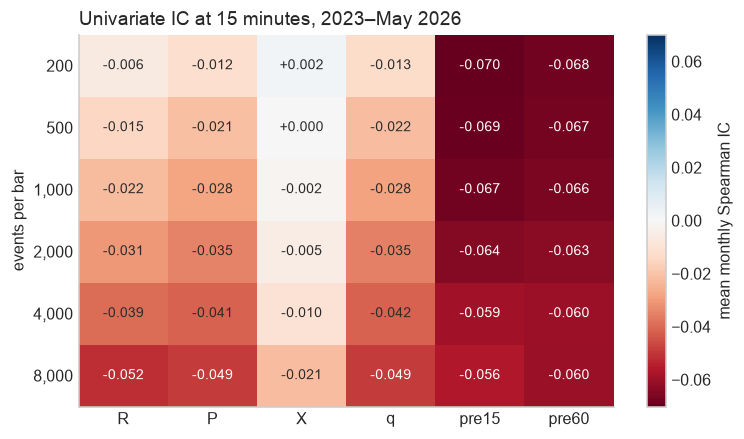

n_events,feature,mean_spearman_ic,spearman_ic_t,negative_month_fraction
i64,str,f64,f64,f64
200,"""P""",-0.012049,-11.627592,0.97561
200,"""R""",-0.006377,-9.418648,0.97561
200,"""X""",0.001957,4.081301,0.243902
200,"""pre15""",-0.070137,-14.307089,1.0
200,"""pre60""",-0.067943,-13.66451,1.0
200,"""q""",-0.012699,-12.557955,1.0
500,"""P""",-0.020976,-16.058281,1.0
500,"""R""",-0.014789,-15.182793,1.0
500,"""X""",0.000309,0.482429,0.512195


In [3]:
features = ['R', 'P', 'X', 'q', 'pre15', 'pre60']
view = univariate.filter(
    (pl.col('horizon_minutes') == HORIZON) & (pl.col('period') == '2023-01..2026-05')
)
grid = np.array([
    [view.filter((pl.col('n_events') == n) & (pl.col('feature') == f))['mean_spearman_ic'][0]
     for f in features]
    for n in SIZES
])
limit = np.abs(grid).max()
fig, ax = plt.subplots(figsize=(7.5, 4.2))
image = ax.imshow(grid, cmap='RdBu', vmin=-limit, vmax=limit, aspect='auto')
ax.set_xticks(range(len(features)), features)
ax.set_yticks(range(len(SIZES)), [f'{n:,}' for n in SIZES])
ax.set_ylabel('events per bar')
ax.grid(False)
for i in range(len(SIZES)):
    for j in range(len(features)):
        ax.text(j, i, f'{grid[i, j]:+.3f}', ha='center', va='center', fontsize=8.5,
                color='white' if abs(grid[i, j]) > 0.6 * limit else INK)
fig.colorbar(image, ax=ax, label='mean monthly Spearman IC')
ax.set_title(f'Univariate IC at {HORIZON} minutes, 2023–May 2026', loc='left')
plt.show()
view.select('n_events', 'feature', 'mean_spearman_ic', 'spearman_ic_t', 'negative_month_fraction')

## 2. The 1:−1 restriction

Within-month OLS of the winsorised future return on $R$ and $P$ (raw volatility
units). The residual imposes $b_R+b_P=0$. Its t-statistic is across months.

In [4]:
fm.filter(pl.col('model') == 'components').select(
    'n_events', 'horizon_minutes', 'months', 'b_R_mean', 'b_R_t', 'b_P_mean', 'b_P_t',
    'b_R_plus_b_P_mean', 'b_R_plus_b_P_t'
).sort('n_events', 'horizon_minutes')

n_events,horizon_minutes,months,b_R_mean,b_R_t,b_P_mean,b_P_t,b_R_plus_b_P_mean,b_R_plus_b_P_t
i64,i64,i64,f64,f64,f64,f64,f64,f64
200,5,53,4.288193,3.233812,-26.782668,-7.518579,-22.494475,-7.634669
200,10,53,6.292092,3.8588,-37.520628,-6.642596,-31.228536,-6.773785
200,15,53,5.805653,3.180854,-33.70547,-5.824666,-27.899817,-6.000495
200,30,53,5.572018,2.506539,-31.788966,-5.216209,-26.216949,-5.671159
500,5,53,3.47376,3.611564,-26.695877,-9.693464,-23.222117,-10.490394
500,10,53,4.910905,4.058493,-34.358601,-8.026094,-29.447697,-8.701902
500,15,53,4.712495,3.252829,-31.667341,-7.3097,-26.954846,-7.91441
500,30,53,5.455913,2.97033,-31.640524,-6.730956,-26.184611,-7.475017
1000,5,53,1.750722,2.130057,-21.995512,-9.971238,-20.24479,-11.595031


## 3. Out-of-sample forecast comparison

Each model is fitted on the preceding 12 months and frozen. The chart shows mean
monthly out-of-sample Spearman IC of each model's forecast (positive = useful)
across bar sizes.

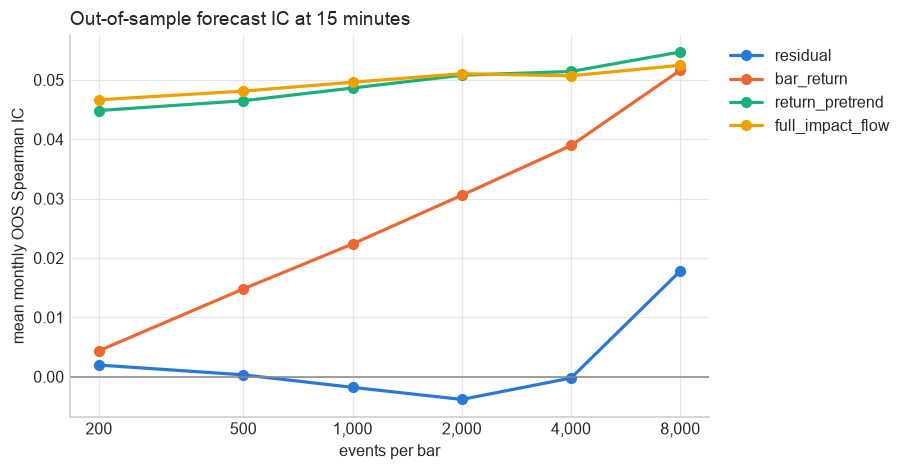

n_events,horizon_minutes,model,months,mean_spearman_ic,spearman_ic_t,positive_month_fraction,mean_pearson_ic_winsorised,mean_oos_r2_winsorised
i64,i64,str,i64,f64,f64,f64,f64,f64
8000,15,"""return_pretrend_flow""",41,0.05514,7.802959,0.926829,0.036861,-0.000172
8000,15,"""full_impact""",41,0.054939,7.877019,0.902439,0.037262,-0.000115
8000,15,"""return_pretrend""",41,0.054713,7.5993,0.902439,0.036089,-0.000235
8000,15,"""full_impact_flow""",41,0.052471,7.205792,0.902439,0.035034,-0.000192
8000,15,"""bar_return""",41,0.051635,13.960155,0.97561,0.025073,0.000543
8000,15,"""components""",41,0.050695,12.480743,0.97561,0.029024,0.00067
8000,15,"""pretrend_only""",41,0.028832,3.178338,0.804878,0.028276,-0.000785
8000,15,"""residual""",41,0.017816,4.343576,0.829268,0.006083,0.000044


In [5]:
selected = oos.filter(pl.col('horizon_minutes') == HORIZON)
fig, ax = plt.subplots(figsize=(8, 4.2))
for model in KEY_MODELS:
    series = selected.filter(pl.col('model') == model).sort('n_events')
    ax.plot(series['n_events'], series['mean_spearman_ic'], marker='o', markersize=6,
            color=MODEL_COLOUR[model], label=model)
ax.set_xscale('log')
ax.set_xticks(SIZES, [f'{n:,}' for n in SIZES])
ax.xaxis.set_minor_formatter(NullFormatter())
ax.axhline(0, color=MUTED, linewidth=1)
ax.set_xlabel('events per bar')
ax.set_ylabel('mean monthly OOS Spearman IC')
ax.set_title(f'Out-of-sample forecast IC at {HORIZON} minutes', loc='left')
ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1.01, 1.0))
plt.tight_layout()
plt.show()
selected.filter(pl.col('n_events') == N_EVENTS).sort('mean_spearman_ic', descending=True)

### Paired increments

Mean monthly difference in OOS IC between nested models, with a t-statistic over
test months. "Adding P" rows are the direct test of whether the impact model is
needed for alpha.

In [6]:
increments.filter(pl.col('horizon_minutes') == HORIZON).select(
    'n_events', 'comparison', 'mean_ic_difference', 'difference_t',
    'candidate_better_month_fraction'
).sort('comparison', 'n_events')

n_events,comparison,mean_ic_difference,difference_t,candidate_better_month_fraction
i64,str,f64,f64,f64
200,"""X versus R alone""",-0.002408,-2.276213,0.365854
500,"""X versus R alone""",-0.014476,-11.623074,0.02439
1000,"""X versus R alone""",-0.024167,-14.939407,0.0
2000,"""X versus R alone""",-0.034409,-14.589198,0.0
4000,"""X versus R alone""",-0.039178,-12.918406,0.02439
8000,"""X versus R alone""",-0.033819,-7.581757,0.121951
200,"""adding P to R""",0.007445,8.722702,0.926829
500,"""adding P to R""",0.005416,7.339756,0.902439
1000,"""adding P to R""",0.004352,5.489181,0.804878


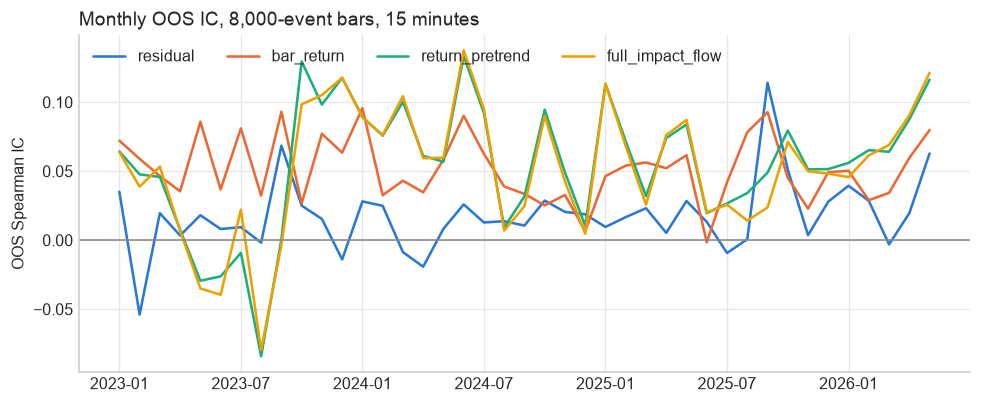

In [7]:
monthly = oos_monthly.filter(
    (pl.col('n_events') == N_EVENTS) & (pl.col('horizon_minutes') == HORIZON)
)
fig, ax = plt.subplots(figsize=(10, 3.8))
for model in KEY_MODELS:
    series = monthly.filter(pl.col('model') == model).sort('test_month')
    ax.plot(range(series.height), series['spearman_ic'], color=MODEL_COLOUR[model],
            label=model, linewidth=1.6)
ticks = series['test_month'].to_list()
ax.set_xticks(range(0, len(ticks), 6), ticks[::6])
ax.axhline(0, color=MUTED, linewidth=1)
ax.set_ylabel('OOS Spearman IC')
ax.set_title(f'Monthly OOS IC, {N_EVENTS:,}-event bars, {HORIZON} minutes', loc='left')
ax.legend(frameon=False, ncol=4, loc='upper left')
plt.show()

## 4. Costed break-even

Trades are taken only when the frozen forecast's magnitude exceeds the training
quantile for the selected tail fraction. Edge is the signed return after a delayed
entry at the first 200-event endpoint at least one second after the decision
(the entry-delay table above gives the realised delay). Trades overlap; the
daily-block t-statistic treats each UTC day as one observation.

Reference lines are round-trip costs at the configured base-tier fees (by default
taker 10 bps and maker 4 bps; edit `costs_bps_per_side` in the config to match
the actual fee tier). Maker fills are not guaranteed and
carry adverse selection, so the maker line is optimistic.

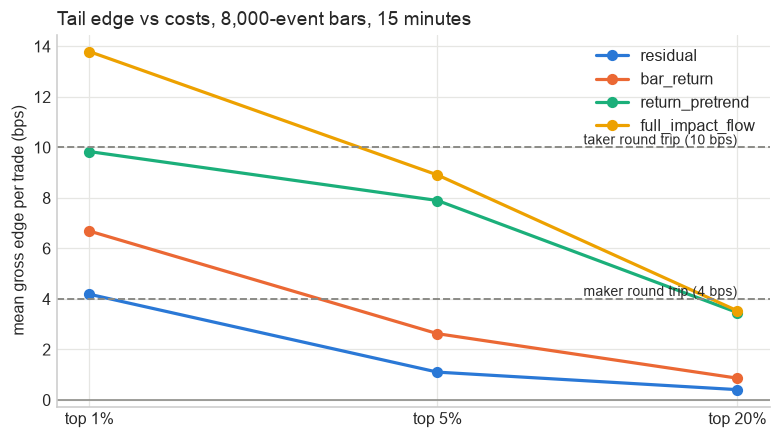

model,tail_fraction,trades_per_day,mean_edge_immediate_bps,mean_edge_delayed_bps,daily_block_t,positive_month_fraction,net_taker_bps,net_maker_bps
str,f64,f64,f64,f64,f64,f64,f64,f64
"""full_impact_flow""",0.01,4.807107,13.646448,13.796407,5.586404,0.756098,3.796407,9.796407
"""full_impact""",0.01,4.24498,10.285117,10.167006,5.269794,0.731707,0.167006,6.167006
"""return_pretrend""",0.01,4.741667,9.819907,9.836506,5.13665,0.682927,-0.163494,5.836506
"""return_pretrend_flow""",0.01,4.114391,8.580055,8.487392,5.346309,0.707317,-1.512608,4.487392
"""bar_return""",0.01,2.456483,6.443178,6.691326,3.972393,0.634146,-3.308674,2.691326
"""residual""",0.01,2.580756,4.018011,4.18891,0.779839,0.585366,-5.81109,0.18891
"""components""",0.01,2.216165,3.354739,3.584858,2.113235,0.609756,-6.415142,-0.415142
"""pretrend_only""",0.01,6.652439,3.593191,3.088214,4.016601,0.525,-6.911786,-0.911786
"""pretrend_only""",0.05,11.005976,9.746307,9.688431,6.20474,0.585366,-0.311569,5.688431


In [8]:
view = tails.filter(
    (pl.col('n_events') == N_EVENTS) & (pl.col('horizon_minutes') == HORIZON)
)
fig, ax = plt.subplots(figsize=(8, 4.2))
fractions = config['tail_fractions']
for model in KEY_MODELS:
    series = view.filter(pl.col('model') == model).sort('tail_fraction')
    ax.plot(series['tail_fraction'] * 100, series['mean_edge_delayed_bps'], marker='o',
            markersize=6, color=MODEL_COLOUR[model], label=model)
for level, label in [(TAKER, 'taker round trip'), (MAKER, 'maker round trip')]:
    ax.axhline(level, color=MUTED, linestyle='--', linewidth=1.2)
    ax.text(fractions[-1] * 100, level, f' {label} ({level:g} bps)', va='bottom',
            ha='right', fontsize=9, color=INK)
ax.set_xscale('log')
ax.set_xticks([f * 100 for f in fractions], [f'top {f:.0%}' for f in fractions])
ax.axhline(0, color=MUTED, linewidth=1)
ax.set_ylabel('mean gross edge per trade (bps)')
ax.set_title(f'Tail edge vs costs, {N_EVENTS:,}-event bars, {HORIZON} minutes',
             loc='left')
ax.legend(frameon=False, loc='upper right')
plt.show()
view.select(
    'model', 'tail_fraction', 'trades_per_day', 'mean_edge_immediate_bps',
    'mean_edge_delayed_bps', 'daily_block_t', 'positive_month_fraction',
    'net_taker_bps', 'net_maker_bps'
).sort('tail_fraction', 'mean_edge_delayed_bps', descending=[False, True])

### Concentration: is the tail edge a steady signal or a few stress days?

Tail trades overlap and cluster, so a daily-block t-statistic can look strong
while almost all the edge comes from a handful of crash or cascade days. The
table reports the share of total edge from the best ten days, the edge on all
other days, and the edge by calendar year. A share above one means the remaining
days lose money in aggregate.

In [9]:
year_columns = [c for c in tails.columns if c.startswith('edge_20')]
tails.filter(pl.col('net_taker_bps') > 0).sort('net_taker_bps', descending=True).select(
    'n_events', 'horizon_minutes', 'model', 'tail_fraction', 'trades_per_day',
    'mean_edge_delayed_bps', 'daily_block_t', 'best_10_day_edge_share',
    'edge_excluding_best_10_days_bps', *year_columns
).head(25)

n_events,horizon_minutes,model,tail_fraction,trades_per_day,mean_edge_delayed_bps,daily_block_t,best_10_day_edge_share,edge_excluding_best_10_days_bps,edge_2023_bps,edge_2024_bps,edge_2025_bps,edge_2026_bps
i64,i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
8000,30,"""pretrend_only""",0.01,7.724832,27.45646,3.264568,1.409612,-13.400338,8.854179,49.658425,45.913292,2.69761
8000,5,"""pretrend_only""",0.01,5.989583,21.227291,6.71351,0.725024,7.028844,18.667612,32.043196,16.724646,12.647727
8000,30,"""return_pretrend_flow""",0.01,5.361905,20.617421,5.29222,1.097826,-2.348546,9.525076,44.743059,13.501578,18.890862
1000,10,"""pretrend_only""",0.01,31.981283,20.362545,9.626101,0.932099,1.596458,20.855567,37.445595,12.818535,3.447019
8000,30,"""full_impact""",0.01,5.278607,19.584564,4.907136,1.139158,-3.072899,8.10478,43.136487,12.881756,15.738046
500,10,"""pretrend_only""",0.01,59.440806,19.564811,10.075947,0.857389,3.185541,25.191796,37.032174,5.424553,4.381855
8000,30,"""return_pretrend""",0.01,5.849741,18.990543,4.695181,1.203171,-4.377938,5.34046,48.835862,11.566488,20.136431
200,10,"""pretrend_only""",0.01,144.585542,18.015511,10.391471,0.871056,2.62647,22.468087,34.215294,5.526548,5.083104
2000,10,"""pretrend_only""",0.01,16.918539,17.753918,8.361182,1.058903,-1.208251,15.244205,36.807202,11.844455,3.799586


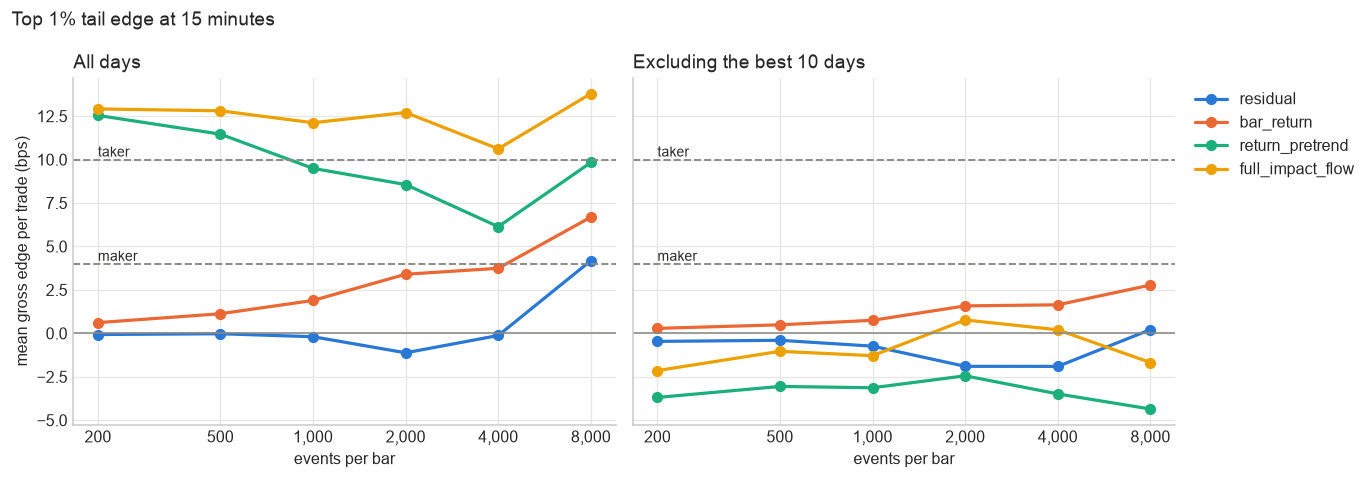

In [10]:
view = tails.filter(
    (pl.col('horizon_minutes') == HORIZON) & (pl.col('tail_fraction') == TAIL_FRACTION)
    & pl.col('model').is_in(KEY_MODELS)
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, column, title in [
    (axes[0], 'mean_edge_delayed_bps', 'All days'),
    (axes[1], 'edge_excluding_best_10_days_bps', 'Excluding the best 10 days'),
]:
    for model in KEY_MODELS:
        series = view.filter(pl.col('model') == model).sort('n_events')
        ax.plot(series['n_events'], series[column], marker='o', markersize=6,
                color=MODEL_COLOUR[model], label=model)
    for level, label in [(TAKER, 'taker'), (MAKER, 'maker')]:
        ax.axhline(level, color=MUTED, linestyle='--', linewidth=1.2)
        ax.text(SIZES[0], level, f'{label} ', va='bottom', ha='left', fontsize=9,
                color=INK)
    ax.axhline(0, color=MUTED, linewidth=1)
    ax.set_xscale('log')
    ax.set_xticks(SIZES, [f'{n:,}' for n in SIZES])
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.set_xlabel('events per bar')
    ax.set_title(title, loc='left')
axes[0].set_ylabel('mean gross edge per trade (bps)')
axes[1].legend(frameon=False, loc='upper left', bbox_to_anchor=(1.01, 1.0))
fig.suptitle(f'Top {TAIL_FRACTION:.0%} tail edge at {HORIZON} minutes', x=0.01,
             ha='left')
plt.tight_layout()
plt.show()

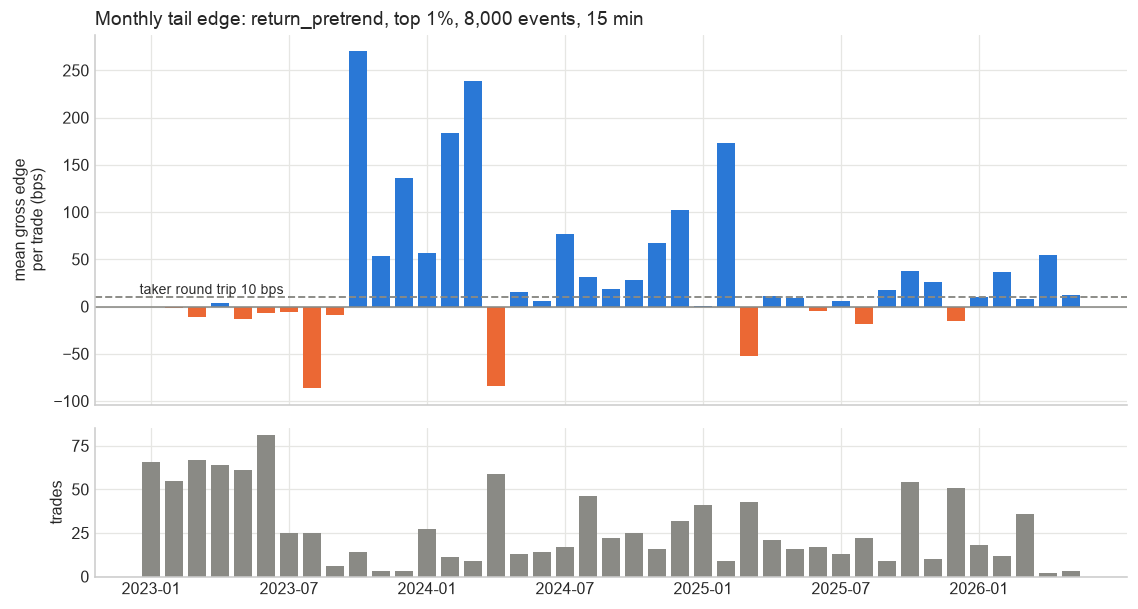

In [11]:
series = tail_monthly.filter(
    (pl.col('n_events') == N_EVENTS) & (pl.col('horizon_minutes') == HORIZON)
    & (pl.col('model') == TAIL_MODEL) & (pl.col('tail_fraction') == TAIL_FRACTION)
).sort('test_month').with_columns(
    (pl.col('sum_edge_delayed_bps') / pl.col('trades')).alias('edge')
)
fig, (ax, count_ax) = plt.subplots(
    2, 1, figsize=(10, 5.4), sharex=True, gridspec_kw={'height_ratios': [3, 1.2]}
)
colours = [SERIES[0] if value >= 0 else SERIES[1] for value in series['edge']]
ax.bar(range(series.height), series['edge'], color=colours, width=0.8)
ax.axhline(TAKER, color=MUTED, linestyle='--', linewidth=1.2)
ax.text(-0.5, TAKER, f'taker round trip {TAKER:g} bps', va='bottom', ha='left',
        fontsize=9, color=INK)
ax.axhline(0, color=MUTED, linewidth=1)
ax.set_ylabel('mean gross edge\nper trade (bps)')
ax.set_title(
    f'Monthly tail edge: {TAIL_MODEL}, top {TAIL_FRACTION:.0%}, '
    f'{N_EVENTS:,} events, {HORIZON} min', loc='left'
)
count_ax.bar(range(series.height), series['trades'], color=MUTED, width=0.8)
count_ax.set_ylabel('trades')
ticks = series['test_month'].to_list()
count_ax.set_xticks(range(0, len(ticks), 6), ticks[::6])
plt.tight_layout()
plt.show()

## 5. Pretrend refresh

The earlier aligned-pretrend evidence came from 2020–21. In signed-price terms
the aligned pretrend is simply the pretrend return, so its univariate IC is shown
for 2022 and for the 2023–May 2026 test period.

In [12]:
univariate.filter(pl.col('feature').is_in(['pre15', 'pre60'])).filter(
    pl.col('horizon_minutes') == HORIZON
).select('n_events', 'feature', 'period', 'months', 'mean_spearman_ic',
         'spearman_ic_t', 'negative_month_fraction').sort('feature', 'n_events', 'period')

n_events,feature,period,months,mean_spearman_ic,spearman_ic_t,negative_month_fraction
i64,str,str,i64,f64,f64,f64
200,"""pre15""","""2022-01..2022-12""",12,-0.06145,-4.552037,0.916667
200,"""pre15""","""2023-01..2026-05""",41,-0.070137,-14.307089,1.0
500,"""pre15""","""2022-01..2022-12""",12,-0.059295,-4.498579,0.916667
500,"""pre15""","""2023-01..2026-05""",41,-0.069149,-14.116039,1.0
1000,"""pre15""","""2022-01..2022-12""",12,-0.055926,-4.422717,0.916667
1000,"""pre15""","""2023-01..2026-05""",41,-0.067489,-13.836299,1.0
2000,"""pre15""","""2022-01..2022-12""",12,-0.050235,-4.231201,0.916667
2000,"""pre15""","""2023-01..2026-05""",41,-0.064377,-13.217603,1.0
4000,"""pre15""","""2022-01..2022-12""",12,-0.042819,-4.121917,0.916667


## Reading

See `alpha-search/reports/residual-decomposition-v1-initial-results.md` for the
written interpretation and gate decision.